<div style="background-color: #fff9f9; padding: 25px; border-radius: 15px; border: 1.2px solid #e74c3c; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0 4px 15px rgba(0,0,0,0.1);">
    <div style="display: flex; align-items: center; gap: 20px;">
        <div style="flex: 1;">
            <h1 style="color: #1e1e2f; margin: 0; font-size: 30px; letter-spacing: 1px;">⚡ Hemant Sharma (HKS)</h1>
            <p style="color: #e74c3c; font-size: 18px; margin: 5px 0; font-weight: 700;">Computer Vision & CNN Research Series | Day 04</p>
            <hr style="border: 0; border-top: 3px solid #e74c3c; width: 60px; margin: 15px 0;">
            <p style="color: #455a64; line-height: 1.6; font-size: 15px;">
                I am a <b>CSE Student</b> at PIET, Jaipur. After mastering Optimization and NLP,
                Day 04 marks our transition into <b>Computer Vision (CV)</b>. We explore how
                <b>Convolutional Neural Networks (CNNs)</b> utilize spatial hierarchies to recognize
                patterns and classify complex visual data.
            </p>
            <div style="margin-top: 15px;">
                <span style="background: #fdecea; color: #e74c3c; padding: 6px 14px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 8px;">#ComputerVision</span>
                <span style="background: #e1f5fe; color: #0288d1; padding: 6px 14px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 8px;">#CNN_Architectures</span>
                <span style="background: #efebe9; color: #5d4037; padding: 6px 14px; border-radius: 20px; font-size: 12px; font-weight: bold;">#HKS_DeepLearning</span>
            </div>
        </div>
    </div>
    <div style="margin-top: 22px; border-top: 1.5px solid #eee; padding-top: 15px; display: flex; gap: 25px;">
        <a href="mailto:artist.hks.dev@gmail.com" style="text-decoration: none; color: #263238; font-size: 14px;">📧 <b>Email:</b> artist.hks.dev@gmail.com</a>
        <a href="https://github.com/artisthks" target="_blank" style="text-decoration: none; color: #263238; font-size: 14px;">🔗 <b>LinkedIn:</b> artisthks</a>
    </div>
</div>

# <p style="color:#e74c3c; font-family:sans-serif; text-align:center; font-size:38px; font-weight:bold;">🎓 Day 4 Masterclass: Learning to See</p>
### <p style="text-align:center; color:#34495e; font-size:20px;">Convolutional Neural Networks • Feature Maps • Image Classification</p>

---

<div style="background-color: #fdecea; padding: 20px; border-radius: 10px; border-left: 5px solid #e74c3c;">
    <strong>🎯 Today's Goal:</strong> Transitioning from unstructured data to <b>Spatial Intelligence</b>. We will teach machines to classify images by extracting hierarchical features using <b>CNNs</b>.
</div>

## 🧠 The "Visual Brain" Architecture
CNNs replicate the Human Visual Cortex. Instead of looking at every pixel individually, they look at <b>local patterns</b>:

1. **The Eye (Convolution):** Sliding <b>Kernels</b> (Filters) to detect edges, curves, and textures.
2. **The Filter (ReLU):** Removing the "negative noise" and keeping only active signals.
3. **The Focus (Pooling):** Reducing the map size (Max Pooling) to keep only the most dominant features.
4. **The Decision (Dense):** Flattening the spatial maps into a single vector to perform final classification.

> ⏱️ **Session Duration:** 1.5 Hours | **Dataset:** MNIST Handwritten Digits (28x28 grayscale)

In [2]:
# ── THE VISION TOOLBOX ──────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Global Aesthetic Config
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)

# ── DATA ACQUISITION ────────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalization: Scaling pixels from [0-255] to [0-1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# ── RESHAPING FOR CNN ───────────────────────────────────────────────────
# CNN expects 4D input: (Batch_size, Height, Width, Channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"✅ Lab Ready! | Training Samples: {X_train.shape[0]} | Shape: {X_train.shape[1:]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Lab Ready! | Training Samples: 60000 | Shape: (28, 28, 1)


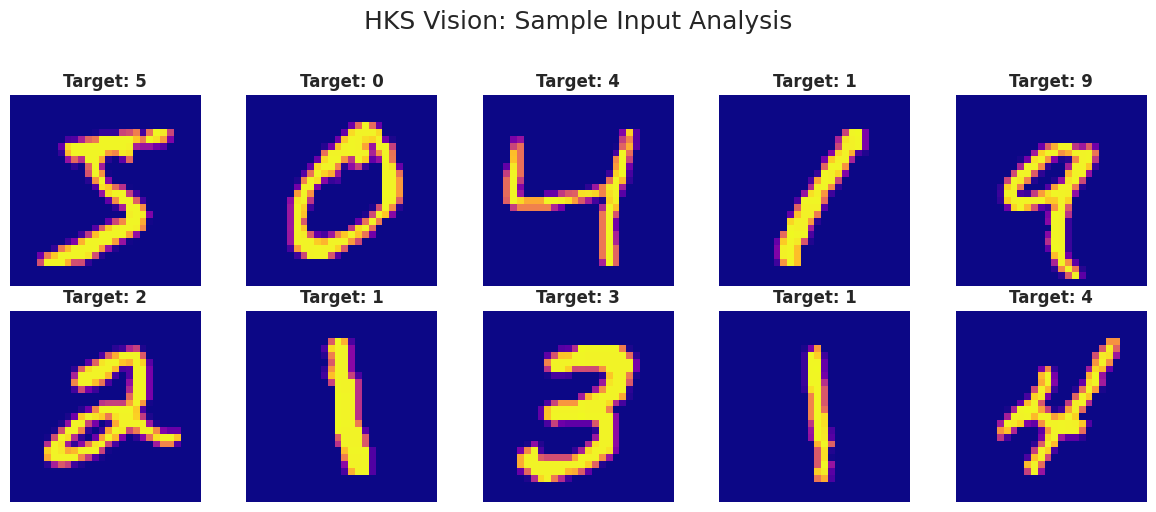

In [3]:
# Visualizing sample digits to understand the classification task
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='plasma') # Using plasma for a modern look
    plt.title(f"Target: {y_train[i]}", fontweight='bold')
    plt.axis('off')
plt.suptitle("HKS Vision: Sample Input Analysis", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# ── BUILDING THE ARCHITECTURE ──────────────────────────────────────────
# We use a 2-stage Feature Extraction followed by a Classifier Head
model = keras.Sequential([
    # Stage 1: Initial Feature Detection (Edges/Corners)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    # Stage 2: Complex Pattern Detection (Shapes)
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Stage 3: Feature Flattening & Global Reasoning
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Adding Regularization (Day 2 Concept!)
    layers.Dense(10, activation='softmax') # Probability distribution over 10 digits
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

🚀 HKS Engine: Commencing Vision Training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.9525 - loss: 0.1562 - val_accuracy: 0.9862 - val_loss: 0.0410
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9840 - loss: 0.0518 - val_accuracy: 0.9877 - val_loss: 0.0363
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9884 - loss: 0.0367 - val_accuracy: 0.9893 - val_loss: 0.0277
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step - accuracy: 0.9907 - loss: 0.0289 - val_accuracy: 0.9911 - val_loss: 0.0292
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9932 - loss: 0.0220 - val_accuracy: 0.9931 - val_loss: 0.0245


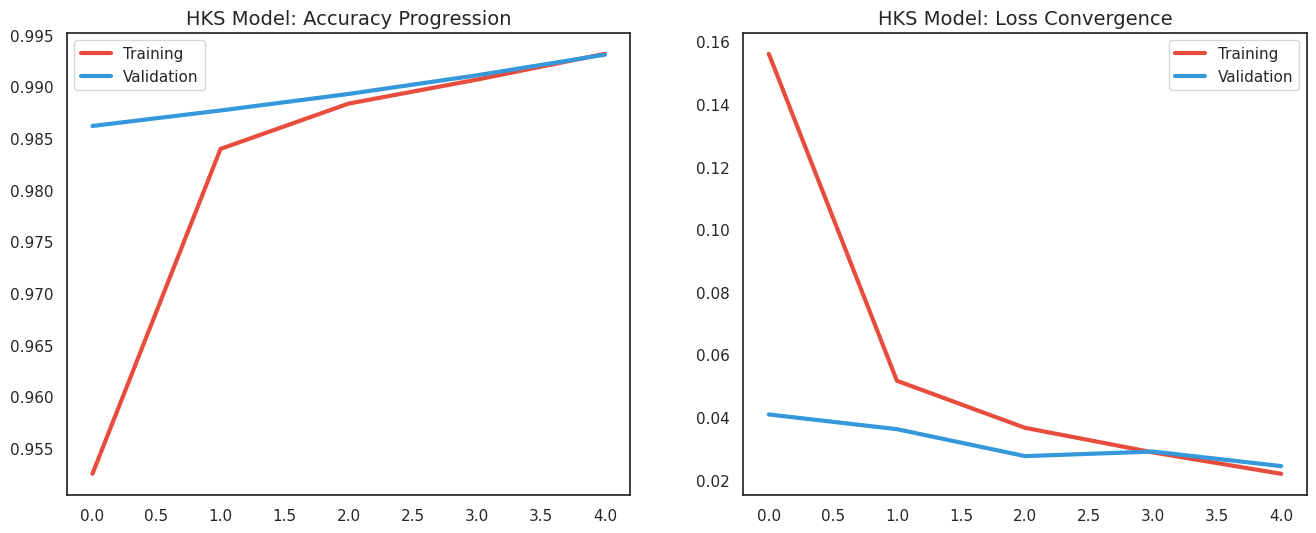

In [5]:
# ── TRAINING PHASE ──────────────────────────────────────────────────────
print("🚀 HKS Engine: Commencing Vision Training...")
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)

# ── PERFORMANCE VISUALIZATION ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training', color='#e74c3c', lw=3)
ax1.plot(history.history['val_accuracy'], label='Validation', color='#3498db', lw=3)
ax1.set_title("HKS Model: Accuracy Progression", fontsize=14)
ax1.legend()

# Loss Plot
ax2.plot(history.history['loss'], label='Training', color='#e74c3c', lw=3)
ax2.plot(history.history['val_loss'], label='Validation', color='#3498db', lw=3)
ax2.set_title("HKS Model: Loss Convergence", fontsize=14)
ax2.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


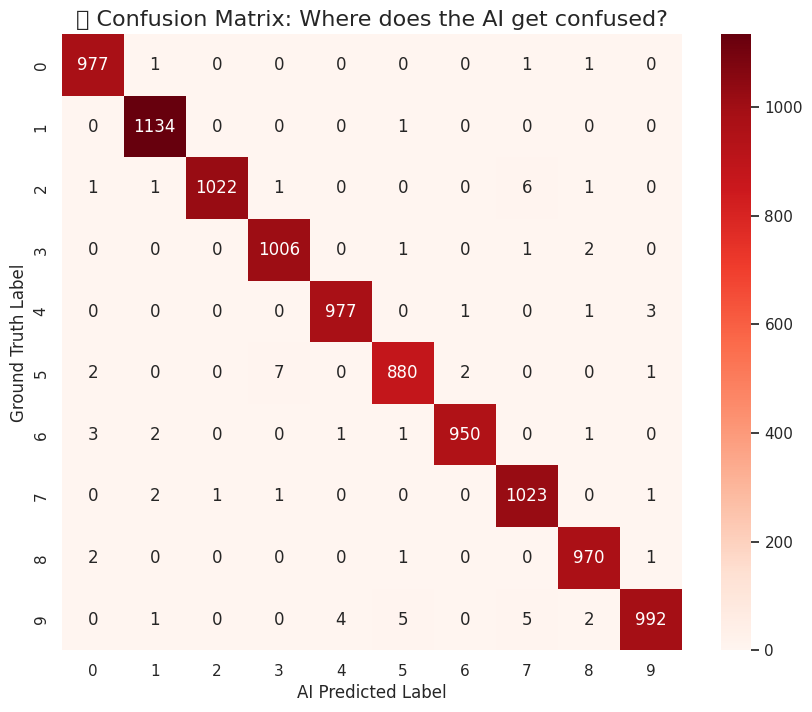

In [7]:
# ── FINAL EVALUATION ────────────────────────────────────────────────────
pred = model.predict(X_test)
y_pred = np.argmax(pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("🩺 Confusion Matrix: Where does the AI get confused?", fontsize=16)
plt.xlabel("AI Predicted Label")
plt.ylabel("Ground Truth Label")
plt.show()

## 📝 Summary of Day 04: Computer Vision Foundations

| Concept | HKS Implementation | Impact |
| :--- | :--- | :--- |
| **Feature Extraction** | `Conv2D` Layers | Automatically learns to see patterns without manual feature engineering. |
| **Downsampling** | `MaxPooling2D` | Reduces computational load and makes the model invariant to slight rotations/shifts. |
| **Regularization** | `Dropout(0.2)` | Applied Day 2 best practices to prevent the model from overfitting on noise. |
| **Output Logic** | `Softmax` | Converts the last layer signals into a 0-1 probability distribution. |

---

## 🎯 Day 4 Mini-Challenge
1. **The Kernel Test:** Change the filter size from `(3,3)` to `(5,5)`. Does the training slow down?
2. **The Deep Test:** Add a third `Conv2D` layer with 128 filters. Watch the accuracy jump!

